# AI Product Advertisement Generator — Stable Diffusion

**Assignment 3 — Image Generation using Stable Diffusion**

**Objective:** Use Stable Diffusion (Image-to-Image) to generate multiple professional
advertisements for the same product across different environments, lighting, camera
angles, and styles — while keeping the product's visual identity intact.

**Chosen product:** Car (Kia Seltos reference image — swap in any product photo of your own)

**Workflow implemented in this notebook:**

`Reference Image → SD Img2Img → Change Environment → Change Camera → Change Lighting → Change Style → Generate Ad → Compare Results`

Run this notebook in **Google Colab** with a GPU runtime:
`Runtime → Change runtime type → T4 GPU (or better)`.


## 1. Setup — Install Dependencies

In [1]:
# Install required libraries. We deliberately do NOT pin numpy: Colab's
# pandas/opencv/etc are already compiled against numpy 2.x, and pinning an
# older diffusers/transformers combo can silently downgrade numpy and break
# pandas with a "numpy.dtype size changed" ValueError. Keeping numpy>=2 avoids that.
!pip install -q --upgrade "numpy>=2" diffusers transformers accelerate safetensors \
                 pillow pandas matplotlib scipy ftfy

print("Setup complete.")
print("If this is the FIRST time you've run this cell in this session, now go to:")
print("  Runtime -> Restart session")
print("...then re-run from the next cell onward (no need to re-run this install cell).")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 6.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 7.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.3/62.3 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 61.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 61.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 83.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 77.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 75.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.3/35.3 MB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas=

In [1]:
import os
import time
import random
import itertools
import json

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

from diffusers import StableDiffusionImg2ImgPipeline, DPMSolverMultistepScheduler

device = "cuda" if torch.cuda.is_available() else "cpu"
dtype = torch.float16 if device == "cuda" else torch.float32
print("Device:", device)

# Output folders (this is also our project structure / deliverable trail)
OUT_DIR = "/content/ad_outputs"
os.makedirs(OUT_DIR, exist_ok=True)


Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Device: cuda


## 2. Load the Stable Diffusion Img2Img Pipeline

We use `runwayml/stable-diffusion-v1-5` with the Img2Img pipeline, since our workflow
starts from a **reference product photo**, not text alone. A faster multistep scheduler
(DPM-Solver++) is swapped in so we can afford more experiments within Colab's time limits.


In [2]:
MODEL_ID = "runwayml/stable-diffusion-v1-5"

pipe = StableDiffusionImg2ImgPipeline.from_pretrained(
    MODEL_ID,
    torch_dtype=dtype,
    safety_checker=None,   # keep default safety checker on if you prefer; off here for speed
)
pipe.scheduler = DPMSolverMultistepScheduler.from_config(pipe.scheduler.config)
pipe = pipe.to(device)
pipe.enable_attention_slicing()

print("Pipeline loaded:", MODEL_ID)


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 13 files:   0%|          | 0/13 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion_img2img.StableDiffusionImg2ImgPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


Pipeline loaded: runwayml/stable-diffusion-v1-5


## 3. Load the Reference Product Image

Upload your product photo (e.g. `kia_seltos.jpg`). It should be a clear, well-lit shot
of the product against a simple background — Img2Img works best when the initial
composition of the subject is already reasonably close to what you want to keep.


Upload your reference product image (e.g. kia_seltos.jpg)


Saving images.jpeg to images (1).jpeg


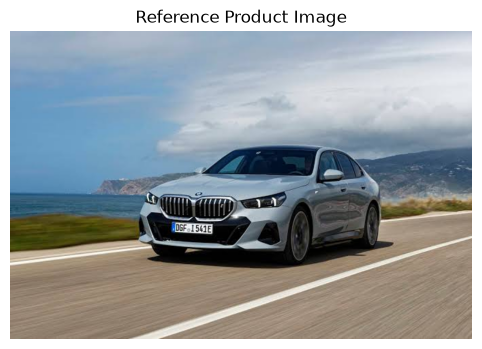

In [4]:
from google.colab import files

print("Upload your reference product image (e.g. kia_seltos.jpg)")
uploaded = files.upload()
REF_IMAGE_PATH = list(uploaded.keys())[0]

def load_and_resize(path, size=(768, 512)):
    img = Image.open(path).convert("RGB")
    img = img.resize(size)
    return img

ref_image = load_and_resize(REF_IMAGE_PATH)
ref_image.save(os.path.join(OUT_DIR, "00_reference_image.png"))

plt.figure(figsize=(6, 4))
plt.imshow(ref_image)
plt.axis("off")
plt.title("Reference Product Image")
plt.show()


## 4. Define the Parameter Space

Everything the assignment asks us to vary lives here in one place, so every experiment
below just pulls from these dictionaries/lists. This keeps prompts, negative prompts,
seeds, CFG scale, steps, and img2img strength fully traceable for the comparison table.


In [5]:
PRODUCT_NAME = "Kia Seltos SUV"   # <-- change to match your chosen product

# --- Prompt variants (Experiment 1: Basic vs Detailed) ---
PROMPTS = {
    "basic":    f"a photo of a {PRODUCT_NAME}",
    "detailed": (
        f"professional advertisement photo of a {PRODUCT_NAME}, sharp focus, "
        f"realistic reflections, showroom quality, high detail, 8k, commercial photography"
    ),
}

# --- Negative prompt variants (Experiment 2: None vs Detailed) ---
NEGATIVE_PROMPTS = {
    "none": "",
    "detailed": (
        "blurry, low quality, distorted, deformed, extra wheels, bad proportions, "
        "watermark, text, logo, cartoon, unrealistic, oversaturated, low resolution"
    ),
}

# --- Seeds (Experiment 3) ---
SEEDS = [42, 101, 999]

# --- CFG scale / guidance scale (Experiment 4) ---
CFG_SCALES = [3, 7, 12]

# --- Inference steps (Experiment 5) ---
INFERENCE_STEPS = [10, 20, 30, 50]

# --- Img2Img strength: how much the image is allowed to change (Experiment 6) ---
STRENGTHS = [0.2, 0.45, 0.7]

# --- Creative axes for the final ad set ---
ENVIRONMENTS = {
    "campus":   "parked on a university campus, students walking nearby, trees, daylight",
    "mountain": "parked on a scenic mountain road, dramatic peaks in the background",
    "city":     "parked on a busy downtown city street, skyscrapers in the background",
    "beach":    "parked on a sandy beach road, ocean waves in the background",
}

LIGHTING = {
    "daylight":    "bright natural daylight, soft shadows",
    "golden_hour": "warm golden hour sunlight, long soft shadows, orange glow",
    "night":       "night time, dramatic artificial lighting, city lights reflecting on the body",
}

CAMERA = {
    "wide_angle": "wide-angle shot, full vehicle in frame",
    "close_up":   "close-up shot, front three-quarter view, detail on grille and headlights",
    "low_angle":  "low-angle heroic shot, looking up at the vehicle",
}

STYLE = {
    "photorealistic": "photorealistic, DSLR photo, natural colors",
    "cinematic":       "cinematic lighting, movie still, dramatic color grading",
    "luxury":          "luxury advertisement style, glossy, high-end magazine editorial",
}

print("Parameter space defined.")


Parameter space defined.


## 5. Prompt Builder & Generation Helper

`build_prompt()` combines the base product prompt with environment / lighting / camera /
style tags. `generate()` wraps a single Img2Img call and logs every parameter used, so we
can build the comparison table automatically instead of by hand.


In [6]:
def build_prompt(base_prompt, environment=None, lighting=None, camera=None, style=None):
    parts = [base_prompt]
    if environment: parts.append(environment)
    if lighting:    parts.append(lighting)
    if camera:      parts.append(camera)
    if style:        parts.append(style)
    return ", ".join(parts)


LOG = []          # every generation call gets logged here -> becomes the comparison table
IMG_COUNTER = 0


def generate(tag, prompt, negative_prompt="", seed=42, cfg=7.5, steps=30, strength=0.5,
             init_image=None, save=True):
    # Run one Img2Img generation and log its parameters + output path.
    global IMG_COUNTER
    init_image = init_image or ref_image
    generator = torch.Generator(device=device).manual_seed(seed)

    t0 = time.time()
    result = pipe(
        prompt=prompt,
        negative_prompt=negative_prompt if negative_prompt else None,
        image=init_image,
        strength=strength,
        guidance_scale=cfg,
        num_inference_steps=steps,
        generator=generator,
    )
    elapsed = time.time() - t0
    out_image = result.images[0]

    IMG_COUNTER += 1
    filename = f"{IMG_COUNTER:03d}_{tag}.png"
    filepath = os.path.join(OUT_DIR, filename)
    if save:
        out_image.save(filepath)

    LOG.append({
        "id": IMG_COUNTER,
        "tag": tag,
        "prompt": prompt,
        "negative_prompt": negative_prompt,
        "seed": seed,
        "cfg_scale": cfg,
        "steps": steps,
        "strength": strength,
        "seconds": round(elapsed, 2),
        "file": filepath,
    })
    return out_image


def show_grid(images, titles, cols=3, figsize_per=(4, 3)):
    rows = int(np.ceil(len(images) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(figsize_per[0]*cols, figsize_per[1]*rows))
    axes = np.array(axes).reshape(-1)
    for ax, img, title in zip(axes, images, titles):
        ax.imshow(img)
        ax.set_title(title, fontsize=9)
        ax.axis("off")
    for ax in axes[len(images):]:
        ax.axis("off")
    plt.tight_layout()
    plt.show()

print("Helpers ready.")


Helpers ready.


## 6. Experiment 1 — Prompt: Basic vs Detailed
Same seed / CFG / steps / strength, only the text prompt changes.


  0%|          | 0/13 [00:00<?, ?it/s]

  0%|          | 0/13 [00:00<?, ?it/s]

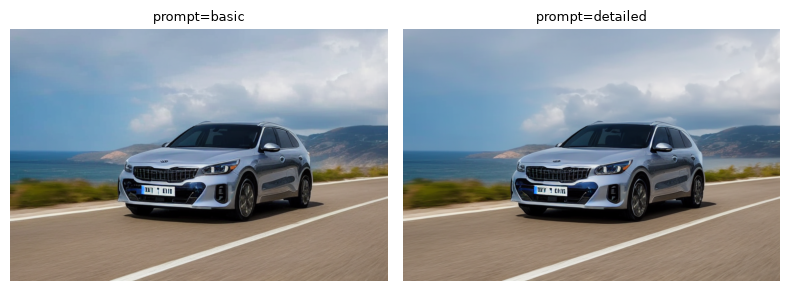

In [7]:
imgs, titles = [], []
for name, prompt in PROMPTS.items():
    img = generate(f"exp1_prompt_{name}", prompt,
                    negative_prompt=NEGATIVE_PROMPTS["detailed"],
                    seed=42, cfg=7, steps=30, strength=0.45)
    imgs.append(img); titles.append(f"prompt={name}")

show_grid(imgs, titles, cols=2)


## 7. Experiment 2 — Negative Prompt: None vs Detailed

  0%|          | 0/13 [00:00<?, ?it/s]

  0%|          | 0/13 [00:00<?, ?it/s]

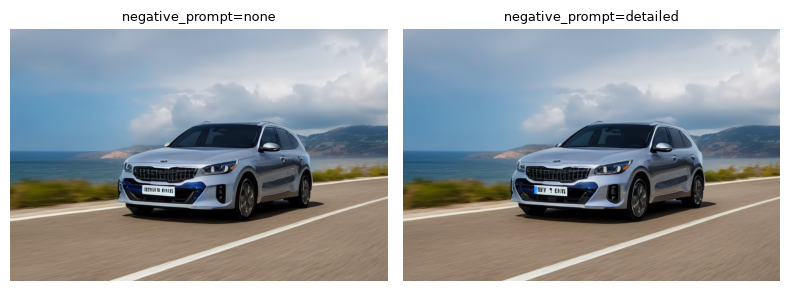

In [8]:
imgs, titles = [], []
for name, neg in NEGATIVE_PROMPTS.items():
    img = generate(f"exp2_negprompt_{name}", PROMPTS["detailed"], negative_prompt=neg,
                    seed=42, cfg=7, steps=30, strength=0.45)
    imgs.append(img); titles.append(f"negative_prompt={name}")

show_grid(imgs, titles, cols=2)


## 8. Experiment 3 — Seed Variation (42, 101, 999)
Same prompt/settings, different seeds — shows how much random variation exists at fixed
parameters, and helps us later pick a "lucky" seed for the final ad set.


  0%|          | 0/13 [00:00<?, ?it/s]

  0%|          | 0/13 [00:00<?, ?it/s]

  0%|          | 0/13 [00:00<?, ?it/s]

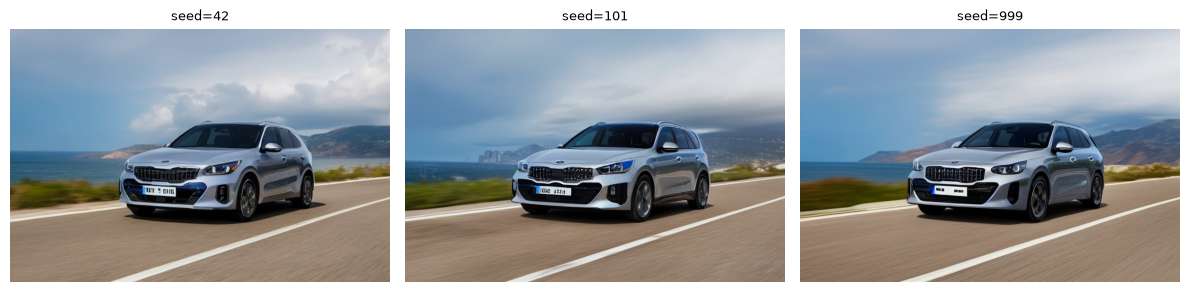

In [9]:
imgs, titles = [], []
for seed in SEEDS:
    img = generate(f"exp3_seed_{seed}", PROMPTS["detailed"],
                    negative_prompt=NEGATIVE_PROMPTS["detailed"],
                    seed=seed, cfg=7, steps=30, strength=0.45)
    imgs.append(img); titles.append(f"seed={seed}")

show_grid(imgs, titles, cols=3)


## 9. Experiment 4 — CFG Scale (3, 7, 12)
Guidance scale controls how strongly the image follows the prompt vs. how much
creative freedom the model keeps.


  0%|          | 0/13 [00:00<?, ?it/s]

  0%|          | 0/13 [00:00<?, ?it/s]

  0%|          | 0/13 [00:00<?, ?it/s]

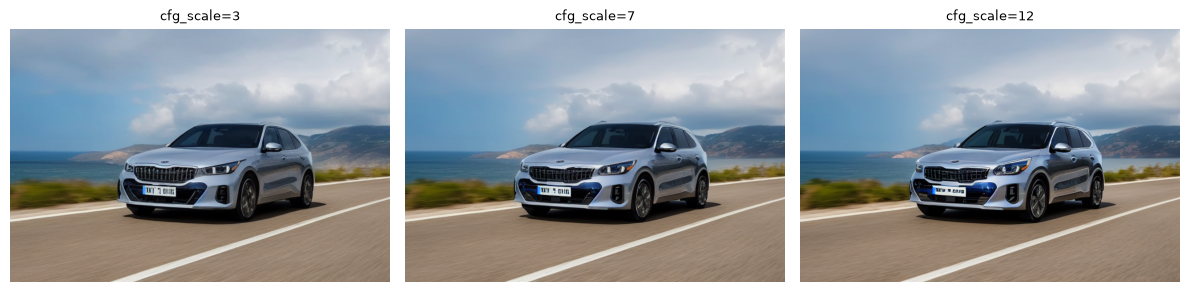

In [10]:
imgs, titles = [], []
for cfg in CFG_SCALES:
    img = generate(f"exp4_cfg_{cfg}", PROMPTS["detailed"],
                    negative_prompt=NEGATIVE_PROMPTS["detailed"],
                    seed=42, cfg=cfg, steps=30, strength=0.45)
    imgs.append(img); titles.append(f"cfg_scale={cfg}")

show_grid(imgs, titles, cols=3)


## 10. Experiment 5 — Inference Steps (10, 20, 30, 50)
More steps generally means more refined detail, at the cost of generation time.


  0%|          | 0/4 [00:00<?, ?it/s]

  0%|          | 0/9 [00:00<?, ?it/s]

  0%|          | 0/13 [00:00<?, ?it/s]

  0%|          | 0/22 [00:00<?, ?it/s]

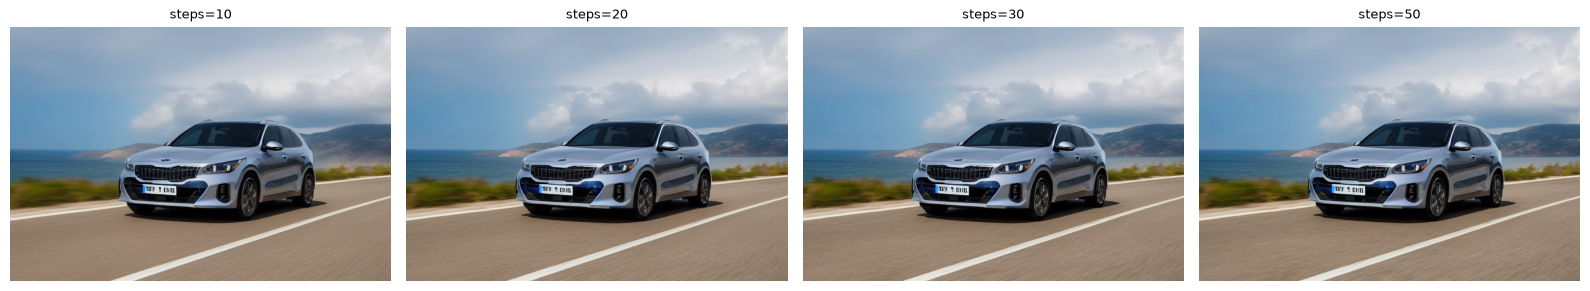

In [11]:
imgs, titles = [], []
for steps in INFERENCE_STEPS:
    img = generate(f"exp5_steps_{steps}", PROMPTS["detailed"],
                    negative_prompt=NEGATIVE_PROMPTS["detailed"],
                    seed=42, cfg=7, steps=steps, strength=0.45)
    imgs.append(img); titles.append(f"steps={steps}")

show_grid(imgs, titles, cols=4)


## 11. Experiment 6 — Img2Img Strength (0.2, 0.45, 0.7)
`strength` controls how far the output is allowed to drift from the reference image.
Low strength = stays close to the original (safer product identity, less creative
freedom). High strength = more dramatic changes to environment/style, but risks losing
the product's exact shape/proportions.


  0%|          | 0/6 [00:00<?, ?it/s]

  0%|          | 0/13 [00:00<?, ?it/s]

  0%|          | 0/21 [00:00<?, ?it/s]

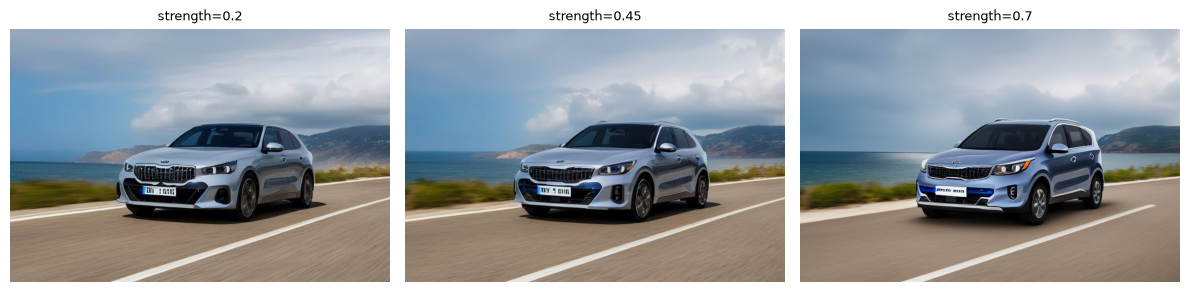

In [12]:
imgs, titles = [], []
for strength in STRENGTHS:
    img = generate(f"exp6_strength_{strength}", PROMPTS["detailed"],
                    negative_prompt=NEGATIVE_PROMPTS["detailed"],
                    seed=42, cfg=7, steps=30, strength=strength)
    imgs.append(img); titles.append(f"strength={strength}")

show_grid(imgs, titles, cols=3)


## 12. Final Advertisement Set — Environment × Lighting × Camera × Style

Using the best single-parameter findings from Experiments 1–6 above (fill these in once
you've looked at the grids), we now generate a curated set of final advertisements. To
keep runtime reasonable we don't do the full 4×3×3×3 = 108-image grid — instead we vary
**one creative axis at a time** around a strong baseline, which is enough to fulfill the
"different environments, lighting, camera angles, and styles" requirement while staying
Colab-friendly. Increase `FULL_GRID = True` below if you want the exhaustive combinatorial
sweep instead (108 images — will take a while on a T4).


  0%|          | 0/13 [00:00<?, ?it/s]

  0%|          | 0/13 [00:00<?, ?it/s]

  0%|          | 0/13 [00:00<?, ?it/s]

  0%|          | 0/13 [00:00<?, ?it/s]

  0%|          | 0/13 [00:00<?, ?it/s]

...

  0%|          | 0/13 [00:00<?, ?it/s]

  0%|          | 0/13 [00:00<?, ?it/s]

  0%|          | 0/13 [00:00<?, ?it/s]

  0%|          | 0/13 [00:00<?, ?it/s]

  0%|          | 0/13 [00:00<?, ?it/s]

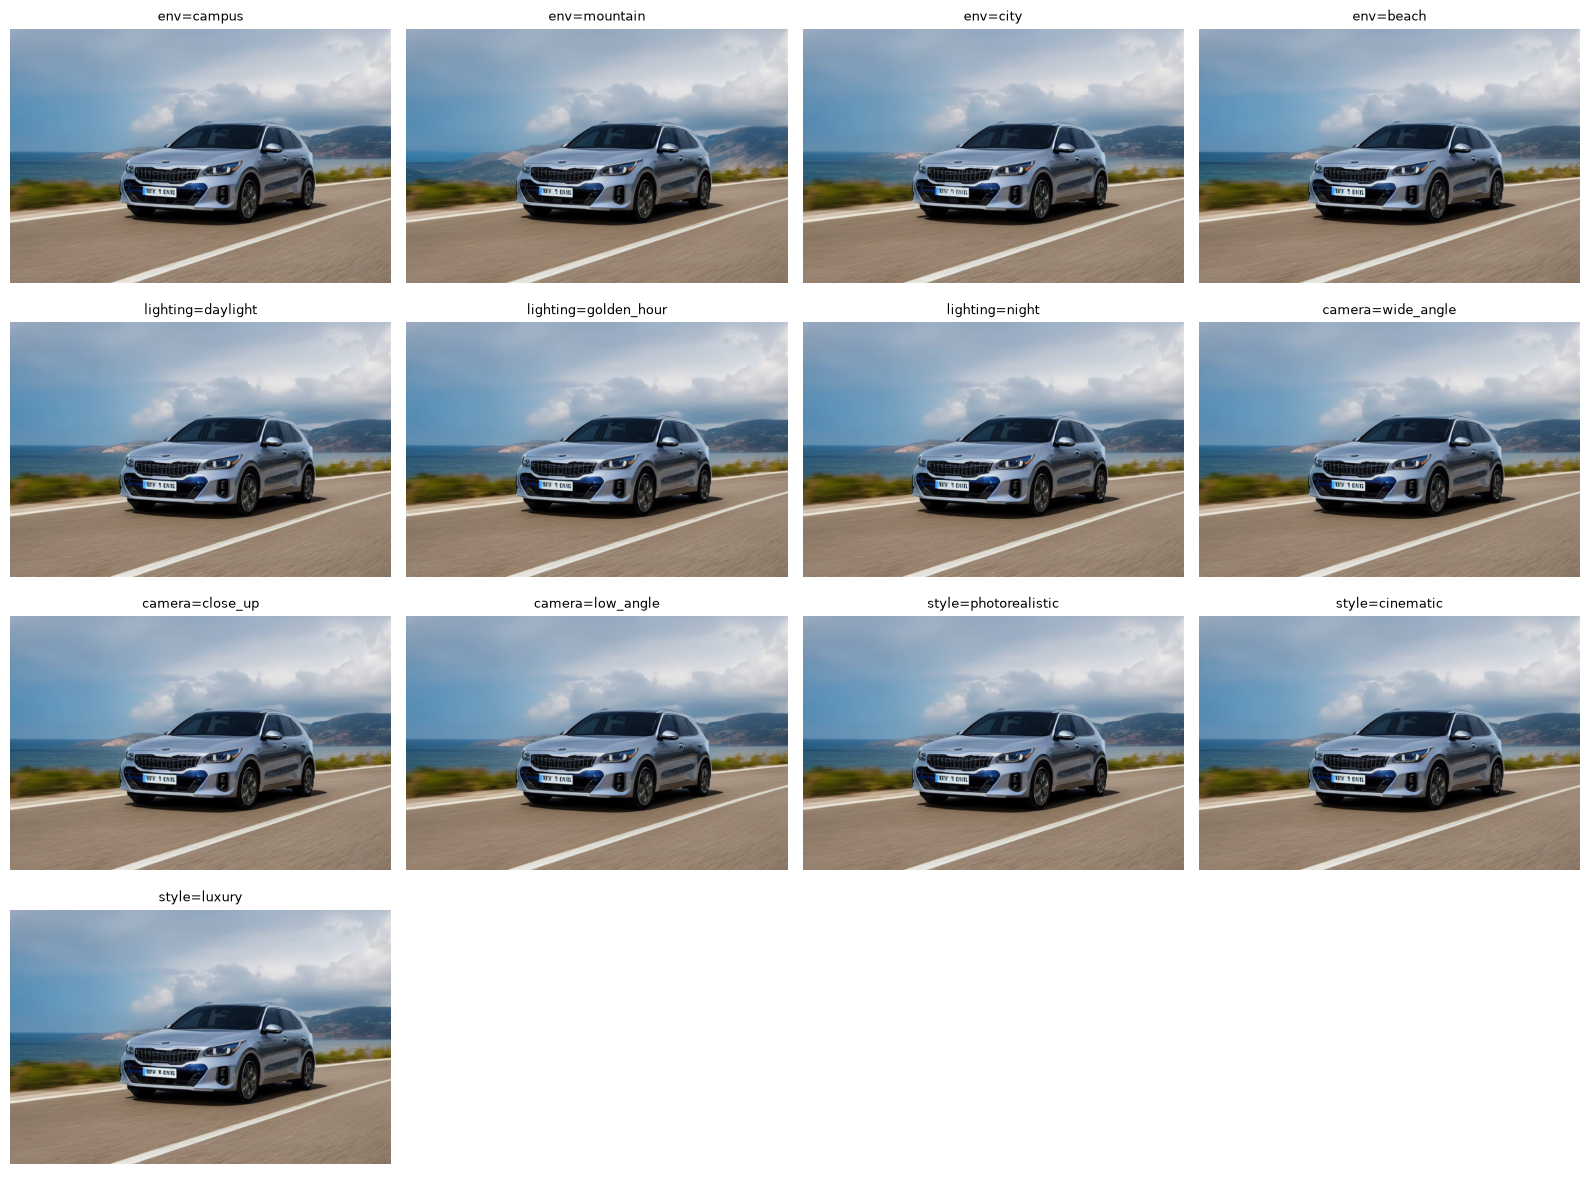

In [13]:
# --- Set these after reviewing Experiments 1-6 ---
BEST_PROMPT_KEY   = "detailed"
BEST_NEGPROMPT_KEY = "detailed"
BEST_SEED   = 42
BEST_CFG    = 7
BEST_STEPS  = 30
BEST_STRENGTH = 0.45

BASE_PROMPT = PROMPTS[BEST_PROMPT_KEY]
BASE_NEG    = NEGATIVE_PROMPTS[BEST_NEGPROMPT_KEY]

FULL_GRID = False  # set True for the exhaustive 4x3x3x3 sweep

final_images, final_titles = [], []

if not FULL_GRID:
    baseline_env, baseline_light, baseline_cam, baseline_style = "campus", "daylight", "wide_angle", "photorealistic"

    # Vary environment, holding the rest at baseline
    for env_key, env_text in ENVIRONMENTS.items():
        prompt = build_prompt(BASE_PROMPT, ENVIRONMENTS[env_key], LIGHTING[baseline_light],
                               CAMERA[baseline_cam], STYLE[baseline_style])
        img = generate(f"final_env_{env_key}", prompt, negative_prompt=BASE_NEG,
                        seed=BEST_SEED, cfg=BEST_CFG, steps=BEST_STEPS, strength=BEST_STRENGTH)
        final_images.append(img); final_titles.append(f"env={env_key}")

    # Vary lighting, holding the rest at baseline
    for light_key, light_text in LIGHTING.items():
        prompt = build_prompt(BASE_PROMPT, ENVIRONMENTS[baseline_env], LIGHTING[light_key],
                               CAMERA[baseline_cam], STYLE[baseline_style])
        img = generate(f"final_light_{light_key}", prompt, negative_prompt=BASE_NEG,
                        seed=BEST_SEED, cfg=BEST_CFG, steps=BEST_STEPS, strength=BEST_STRENGTH)
        final_images.append(img); final_titles.append(f"lighting={light_key}")

    # Vary camera angle, holding the rest at baseline
    for cam_key, cam_text in CAMERA.items():
        prompt = build_prompt(BASE_PROMPT, ENVIRONMENTS[baseline_env], LIGHTING[baseline_light],
                               CAMERA[cam_key], STYLE[baseline_style])
        img = generate(f"final_cam_{cam_key}", prompt, negative_prompt=BASE_NEG,
                        seed=BEST_SEED, cfg=BEST_CFG, steps=BEST_STEPS, strength=BEST_STRENGTH)
        final_images.append(img); final_titles.append(f"camera={cam_key}")

    # Vary style, holding the rest at baseline
    for style_key, style_text in STYLE.items():
        prompt = build_prompt(BASE_PROMPT, ENVIRONMENTS[baseline_env], LIGHTING[baseline_light],
                               CAMERA[baseline_cam], STYLE[style_key])
        img = generate(f"final_style_{style_key}", prompt, negative_prompt=BASE_NEG,
                        seed=BEST_SEED, cfg=BEST_CFG, steps=BEST_STEPS, strength=BEST_STRENGTH)
        final_images.append(img); final_titles.append(f"style={style_key}")

else:
    combos = list(itertools.product(ENVIRONMENTS.items(), LIGHTING.items(),
                                      CAMERA.items(), STYLE.items()))
    print(f"Full grid: {len(combos)} images. This will take a while.")
    for (env_key, env_text), (light_key, light_text), (cam_key, cam_text), (style_key, style_text) in combos:
        prompt = build_prompt(BASE_PROMPT, env_text, light_text, cam_text, style_text)
        tag = f"full_{env_key}_{light_key}_{cam_key}_{style_key}"
        img = generate(tag, prompt, negative_prompt=BASE_NEG,
                        seed=BEST_SEED, cfg=BEST_CFG, steps=BEST_STEPS, strength=BEST_STRENGTH)
        final_images.append(img); final_titles.append(tag)

show_grid(final_images, final_titles, cols=4)


## 13. Comparison Table

Every generation call above was logged automatically in `LOG`. This becomes our
parameter comparison table — prompt, negative prompt, seed, CFG scale, steps,
img2img strength, generation time, and the saved file path for each image.


In [14]:
df = pd.DataFrame(LOG)
df_path = os.path.join(OUT_DIR, "comparison_table.csv")
df.to_csv(df_path, index=False)

pd.set_option("display.max_colwidth", 60)
df


,id,tag,prompt,negative_prompt,seed,cfg_scale,steps,strength,seconds,file
0,1,exp1_prompt_basic,a photo of a Kia Seltos SUV,"blurry, low quality, distorted, deformed, extra wheels, ...",42,7,30,0.45,6.43,/content/ad_outputs/001_exp1_prompt_basic.png
1,2,exp1_prompt_detailed,"professional advertisement photo of a Kia Seltos SUV, sh...","blurry, low quality, distorted, deformed, extra wheels, ...",42,7,30,0.45,5.02,/content/ad_outputs/002_exp1_prompt_detailed.png
2,3,exp2_negprompt_none,"professional advertisement photo of a Kia Seltos SUV, sh...",,42,7,30,0.45,5.18,/content/ad_outputs/003_exp2_negprompt_none.png
3,4,exp2_negprompt_detailed,"professional advertisement photo of a Kia Seltos SUV, sh...","blurry, low quality, distorted, deformed, extra wheels, ...",42,7,30,0.45,5.25,/content/ad_outputs/004_exp2_negprompt_detailed.png
4,5,exp3_seed_42,"professional advertisement photo of a Kia Seltos SUV, sh...","blurry, low quality, distorted, deformed, extra wheels, ...",42,7,30,0.45,5.28,/content/ad_outputs/005_exp3_seed_42.png
5,6,exp3_seed_101,"professional advertisement photo of a Kia Seltos SUV, sh...","blurry, low quality, distorted, deformed, extra wheels, ...",101,7,30,0.45,5.40,/content/ad_outputs/006_exp3_seed_101.png
6,7,exp3_seed_999,"professional advertisement photo of a Kia Seltos SUV, sh...","blurry, low quality, distorted, deformed, extra wheels, ...",999,7,30,0.45,5.52,/content/ad_outputs/007_exp3_seed_999.png
7,8,exp4_cfg_3,"professional advertisement photo of a Kia Seltos SUV, sh...","blurry, low quality, distorted, deformed, extra wheels, ...",42,3,30,0.45,5.59,/content/ad_outputs/008_exp4_cfg_3.png
8,9,exp4_cfg_7,"professional advertisement photo of a Kia Seltos SUV, sh...","blurry, low quality, distorted, deformed, extra wheels, ...",42,7,30,0.45,5.71,/content/ad_outputs/009_exp4_cfg_7.png
9,10,exp4_cfg_12,"professional advertisement photo of a Kia Seltos SUV, sh...","blurry, low quality, distorted, deformed, extra wheels, ...",42,12,30,0.45,5.86,/content/ad_outputs/010_exp4_cfg_12.png


## 14. Scoring Images — Prompt Alignment & Product-Identity Preservation

To pick the "best" prompt + parameter combination objectively (not just by eye), we use
CLIP to score two things for every generated image:

1. **Prompt alignment** — cosine similarity between the image and its own text prompt
   (higher = better follows the ad brief).
2. **Identity preservation** — cosine similarity between the generated image and the
   original reference image (higher = keeps the product's visual identity intact).

A good advertisement image should score reasonably well on **both** axes — a combined
score balances them.


In [16]:
from transformers import CLIPModel, CLIPProcessor

clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(device)
clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

def _as_tensor(feat):
    """Some transformers versions return a wrapped output object instead of
    a raw tensor from get_image_features/get_text_features. Unwrap it if so."""
    if torch.is_tensor(feat):
        return feat
    for attr in ("image_embeds", "text_embeds", "pooler_output"):
        if hasattr(feat, attr):
            return getattr(feat, attr)
    raise TypeError(f"Unexpected CLIP output type: {type(feat)}")

@torch.no_grad()
def clip_image_embed(img):
    inputs = clip_processor(images=img, return_tensors="pt").to(device)
    feat = _as_tensor(clip_model.get_image_features(**inputs))
    return feat / feat.norm(dim=-1, keepdim=True)

@torch.no_grad()
def clip_text_embed(text):
    inputs = clip_processor(text=[text], return_tensors="pt", padding=True, truncation=True).to(device)
    feat = _as_tensor(clip_model.get_text_features(**inputs))
    return feat / feat.norm(dim=-1, keepdim=True)

ref_embed = clip_image_embed(ref_image)

prompt_scores, identity_scores = [], []
for row in LOG:
    img = Image.open(row["file"]).convert("RGB")
    img_embed = clip_image_embed(img)
    txt_embed = clip_text_embed(row["prompt"])

    prompt_sim = (img_embed @ txt_embed.T).item()
    identity_sim = (img_embed @ ref_embed.T).item()

    prompt_scores.append(round(prompt_sim, 4))
    identity_scores.append(round(identity_sim, 4))

df["clip_prompt_alignment"] = prompt_scores
df["clip_identity_preservation"] = identity_scores
df["combined_score"] = (df["clip_prompt_alignment"] + df["clip_identity_preservation"]) / 2

df.sort_values("combined_score", ascending=False).to_csv(df_path, index=False)
df.sort_values("combined_score", ascending=False).head(10)

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

,id,tag,prompt,negative_prompt,seed,cfg_scale,steps,strength,seconds,file,clip_prompt_alignment,clip_identity_preservation,combined_score
14,15,exp6_strength_0.2,"professional advertisement photo of a Kia Seltos SUV, sh...","blurry, low quality, distorted, deformed, extra wheels, ...",42,7,30,0.20,3.40,/content/ad_outputs/015_exp6_strength_0.2.png,0.2268,0.9510,0.58890
7,8,exp4_cfg_3,"professional advertisement photo of a Kia Seltos SUV, sh...","blurry, low quality, distorted, deformed, extra wheels, ...",42,3,30,0.45,5.59,/content/ad_outputs/008_exp4_cfg_3.png,0.2532,0.9239,0.58855
6,7,exp3_seed_999,"professional advertisement photo of a Kia Seltos SUV, sh...","blurry, low quality, distorted, deformed, extra wheels, ...",999,7,30,0.45,5.52,/content/ad_outputs/007_exp3_seed_999.png,0.2568,0.9123,0.58455
5,6,exp3_seed_101,"professional advertisement photo of a Kia Seltos SUV, sh...","blurry, low quality, distorted, deformed, extra wheels, ...",101,7,30,0.45,5.40,/content/ad_outputs/006_exp3_seed_101.png,0.2914,0.8662,0.57880
2,3,exp2_negprompt_none,"professional advertisement photo of a Kia Seltos SUV, sh...",,42,7,30,0.45,5.18,/content/ad_outputs/003_exp2_negprompt_none.png,0.2690,0.8869,0.57795
13,14,exp5_steps_50,"professional advertisement photo of a Kia Seltos SUV, sh...","blurry, low quality, distorted, deformed, extra wheels, ...",42,7,50,0.45,10.53,/content/ad_outputs/014_exp5_steps_50.png,0.2731,0.8787,0.57590
12,13,exp5_steps_30,"professional advertisement photo of a Kia Seltos SUV, sh...","blurry, low quality, distorted, deformed, extra wheels, ...",42,7,30,0.45,6.19,/content/ad_outputs/013_exp5_steps_30.png,0.2692,0.8818,0.57550
4,5,exp3_seed_42,"professional advertisement photo of a Kia Seltos SUV, sh...","blurry, low quality, distorted, deformed, extra wheels, ...",42,7,30,0.45,5.28,/content/ad_outputs/005_exp3_seed_42.png,0.2692,0.8818,0.57550
1,2,exp1_prompt_detailed,"professional advertisement photo of a Kia Seltos SUV, sh...","blurry, low quality, distorted, deformed, extra wheels, ...",42,7,30,0.45,5.02,/content/ad_outputs/002_exp1_prompt_detailed.png,0.2692,0.8818,0.57550
8,9,exp4_cfg_7,"professional advertisement photo of a Kia Seltos SUV, sh...","blurry, low quality, distorted, deformed, extra wheels, ...",42,7,30,0.45,5.71,/content/ad_outputs/009_exp4_cfg_7.png,0.2692,0.8818,0.57550


## 15. Best Prompt + Best Parameter Combination

BEST COMBINATION
------------------------------------------------------------
Tag:                  exp6_strength_0.2
Prompt:                professional advertisement photo of a Kia Seltos SUV, sharp focus, realistic reflections, showroom quality, high detail, 8k, commercial photography
Negative prompt:       blurry, low quality, distorted, deformed, extra wheels, bad proportions, watermark, text, logo, cartoon, unrealistic, oversaturated, low resolution
Seed:                  42
CFG scale:             7
Inference steps:       30
Img2Img strength:      0.2
CLIP prompt alignment: 0.2268
CLIP identity score:   0.951
Combined score:        0.5889


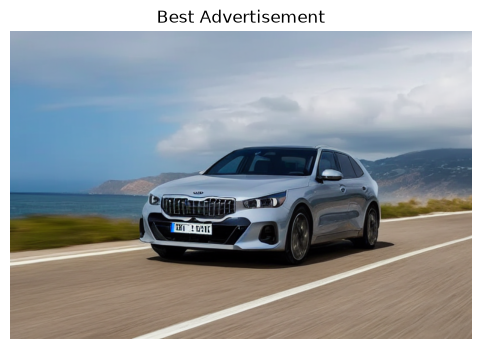

In [17]:
best_row = df.sort_values("combined_score", ascending=False).iloc[0]

print("BEST COMBINATION")
print("-" * 60)
print(f"Tag:                  {best_row['tag']}")
print(f"Prompt:                {best_row['prompt']}")
print(f"Negative prompt:       {best_row['negative_prompt']}")
print(f"Seed:                  {best_row['seed']}")
print(f"CFG scale:             {best_row['cfg_scale']}")
print(f"Inference steps:       {best_row['steps']}")
print(f"Img2Img strength:      {best_row['strength']}")
print(f"CLIP prompt alignment: {best_row['clip_prompt_alignment']}")
print(f"CLIP identity score:   {best_row['clip_identity_preservation']}")
print(f"Combined score:        {round(best_row['combined_score'], 4)}")

best_img = Image.open(best_row["file"])
plt.figure(figsize=(6, 4))
plt.imshow(best_img)
plt.axis("off")
plt.title("Best Advertisement")
plt.show()


## 16. Deliverables Summary

This notebook produces everything required for submission:

| # | Deliverable | Where it lives |
|---|---|---|
| 1 | Original reference image | `ad_outputs/00_reference_image.png` |
| 2 | Prompts used | `PROMPTS` dict (Section 4) + `prompt` column in `df` |
| 3 | Negative prompts | `NEGATIVE_PROMPTS` dict (Section 4) + `negative_prompt` column |
| 4 | Parameter values | `df` columns: seed, cfg_scale, steps, strength |
| 5 | Generated images | `ad_outputs/*.png`, shown inline via `show_grid()` |
| 6 | Comparison table | `ad_outputs/comparison_table.csv`, `df` in Section 13–14 |
| 7 | Best prompt + parameter combination | Section 15 |

Run the cell below to zip everything for download / submission.


In [18]:
import shutil
zip_path = "/content/ad_outputs"
shutil.make_archive(zip_path, "zip", OUT_DIR)
print("Saved:", zip_path + ".zip")

from google.colab import files
files.download(zip_path + ".zip")


Saved: /content/ad_outputs.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>